In [1]:
import sys
import metpy.calc as mpcalc
import metpy.units as units
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import tqdm
import glob
from dask.distributed import Client
import pandas as pd

sys.path.append('/g/data/ng72/ab4502/hot-cloudy/modules/')
from fronts import *

In [2]:
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42431,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33513,Total threads: 2
Dashboard: /proxy/33859/status,Memory: 9.00 GiB
Nanny: tcp://127.0.0.1:39349,


In [3]:
#Load in CAPE for the entire Nov-Apr 2015-2024 period

cape_type = "MUCAPE"

cape_files = np.sort(glob.glob("/g/data/ob53/BARRA2/output/reanalysis/AUST-11/BOM/ERA5/historical/hres/BARRA-R2/v1/1hr/"+cape_type+"/latest/*"))
cape_file_years = np.array([int(cape_files[i].split("/")[-1].split("_")[-1].split("-")[0][0:4]) for i in np.arange(len(cape_files))])
cape_file_months = np.array([int(cape_files[i].split("/")[-1].split("_")[-1].split("-")[0][4:]) for i in np.arange(len(cape_files))])

cape_all = xr.open_mfdataset(
    cape_files[(cape_file_years >= 2015) & (cape_file_years <= 2024) & (np.in1d(cape_file_months,[11,12,1,2,3,4]))],
    chunks={"lat":-1,"lon":-1}).sel(lat=slice(-45,-10),lon=slice(110,160))

cape_all = cape_all.sel(time=np.in1d(cape_all.time.dt.hour,[0,1,2,3,4,5,6,7]))
cape_all_daily = cape_all.groupby(cape_all.time.dt.date).max()[cape_type].persist()

In [4]:
#Load in huss for the entire Nov-Apr 2015-2024 period

huss_files = np.sort(glob.glob("/g/data/ob53/BARRA2/output/reanalysis/AUS-11/BOM/ERA5/historical/hres/BARRA-R2/v1/1hr/hus850/latest/*"))
huss_file_years = np.array([int(huss_files[i].split("/")[-1].split("_")[-1].split("-")[0][0:4]) for i in np.arange(len(huss_files))])
huss_file_months = np.array([int(huss_files[i].split("/")[-1].split("_")[-1].split("-")[0][4:]) for i in np.arange(len(huss_files))])

huss_all = xr.open_mfdataset(
    huss_files[(huss_file_years >= 2015) & (huss_file_years <= 2024) & (np.in1d(huss_file_months,[11,12,1,2,3,4]))],
    chunks={"lat":-1,"lon":-1}).sel(lat=slice(-45,-10),lon=slice(110,160))

huss_all = huss_all.sel(time=np.in1d(huss_all.time.dt.hour,[0,1,2,3,4,5,6,7]))
huss_all_daily = huss_all.groupby(huss_all.time.dt.date).mean().hus850.persist()

In [5]:
#Open fronts data for the entire Nov-Apr 2015-2024 period
front_f = xr.open_mfdataset("/g/data/gb02/ab4502/hot_cloudy/fronts/*.nc")
front_f = front_f.sel(time=np.in1d(front_f.time.dt.hour,[0,1,2,3,4,5,6,7]))
f_daily = front_f.groupby(front_f.time.dt.date).max().barra_r_front_850hPa

In [6]:
from rasterio import features
from affine import Affine
import geopandas as gpd

def transform_from_latlon(lat, lon):
    lat = np.asarray(lat)
    lon = np.asarray(lon)
    trans = Affine.translation(lon[0], lat[0])
    scale = Affine.scale(lon[1] - lon[0], lat[1] - lat[0])
    return trans * scale

def rasterize(shapes, coords, fill=np.nan, **kwargs):
    """Rasterize a list of (geometry, fill_value) tuples onto the given
    xray coordinates. This only works for 1d latitude and longitude
    arrays.
    """
    transform = transform_from_latlon(coords['lat'], coords['lon'])
    out_shape = (len(coords['lat']), len(coords['lon']))
    raster = features.rasterize(shapes, out_shape=out_shape,
                                fill=fill, transform=transform,
                                dtype=float, **kwargs)
    return xr.DataArray(raster, coords=coords, dims=('lat', 'lon'))

#Load greater metro regions 
f=gpd.read_file("/g/data/ng72/ab4502/coastline_data/GCCSA_2021_AUST_SHP_GDA2020/").loc[[0,4,8,12]]
shapes = [(shape, n) for n, shape in enumerate(f.geometry)]


In [16]:
def sum_cape_front(thresh):

    raster_ind = {"GSYD":0,"GMEL":1,"GBRI":2,"GADE":3}
    
    cape_regional_cases = []
    cape_regional_nulls = []
    cape_regional_non = []
    
    huss_regional_cases = []
    huss_regional_nulls = []
    huss_regional_non = []
    
    front_regional_cases = []
    front_regional_nulls = []
    front_regional_non = []
    
    front_freq_ls_cases = []
    front_freq_ls_nulls = []
    
    cape_mean_cases = []
    cape_mean_nulls = []
    
    for region in ["GBRI","GSYD","GMEL","GADE"]:
    
        #Read hot cloudy dates for the region
        dates = pd.read_csv("/g/data/ng72/ab4502/hot-cloudy/data/event_dates_csi0p5_thourly90_counts.csv",index_col=0)
        dates["time"] = pd.to_datetime(dates.index)
        dates = dates[(dates.region == region) & (dates.nhours >= thresh)]
        cases = dates.time
        
        #Read null event dates for the region (hot and not cloudy)
        dates = pd.read_csv("/g/data/ng72/ab4502/hot-cloudy/data/null_event_dates_csi0p5_thourly90_nhours7.csv",index_col=0)
        dates["time"] = pd.to_datetime(dates.index)
        dates = dates[(dates.region==region)]
        nulls = dates.time
    
        #Get No-Event dates
        non_events = cape_all_daily.date.values
        non_events = non_events[np.in1d(non_events,[dt.date(d.year,d.month,d.day) for d in cases],invert=True)]
        non_events = non_events[np.in1d(non_events,[dt.date(d.year,d.month,d.day) for d in nulls],invert=True)]
    
        print(region,"\nCases:",cases.shape[0],"\nNulls:",nulls.shape[0],"\nNon-events:",non_events.shape[0],)
        
        #Calculate mean daily max CAPE for the region, for each set of dates
        raster_cape = rasterize(shapes,{"lat":cape_all_daily.lat,"lon":cape_all_daily.lon},fill=np.nan)
        cape_regional_cases.append(
            xr.where(raster_cape==raster_ind[region],
                     cape_all_daily.sel(date=[dt.date(d.year,d.month,d.day) for d in cases]),
                     np.nan).mean(("lat","lon")).values)
        cape_regional_nulls.append(
            xr.where(raster_cape==raster_ind[region],
                     cape_all_daily.sel(date=[dt.date(d.year,d.month,d.day) for d in nulls]),
                     np.nan).mean(("lat","lon")).values)
        cape_regional_non.append(
            xr.where(raster_cape==raster_ind[region],
                     cape_all_daily.sel(date=[dt.date(d.year,d.month,d.day) for d in non_events]),
                     np.nan).mean(("lat","lon")).values)
    
        #Calculate mean daily mean huss for the region, for each set of dates
        raster_huss = rasterize(shapes,{"lat":huss_all_daily.lat,"lon":huss_all_daily.lon},fill=np.nan)
        huss_regional_cases.append(
            xr.where(raster_huss==raster_ind[region],
                     huss_all_daily.sel(date=[dt.date(d.year,d.month,d.day) for d in cases]),
                     np.nan).mean(("lat","lon")).values)
        huss_regional_nulls.append(
            xr.where(raster_huss==raster_ind[region],
                     huss_all_daily.sel(date=[dt.date(d.year,d.month,d.day) for d in nulls]),
                     np.nan).mean(("lat","lon")).values)
        huss_regional_non.append(
            xr.where(raster_huss==raster_ind[region],
                     huss_all_daily.sel(date=[dt.date(d.year,d.month,d.day) for d in non_events]),
                     np.nan).mean(("lat","lon")).values)    
    
        #Calculate frequency of days with a front within 5 degrees lat/lon
        raster_front = rasterize(shapes,{"lat":f_daily.lat,"lon":f_daily.lon},fill=np.nan)
        xx,yy = np.meshgrid(raster_front.lon.values,raster_front.lat.values)
        x_region = xr.where(raster_front==raster_ind[region],xx,np.nan).mean().values
        y_region = xr.where(raster_front==raster_ind[region],yy,np.nan).mean().values
        front_regional_cases.append(
            xr.where(
                (np.sqrt((xx-x_region)**2 + (yy-y_region)**2) < 5),
                f_daily.sel(date=[dt.date(d.year,d.month,d.day) for d in cases]), 
                np.nan).max(("lat","lon")).mean().values
        )
        front_regional_nulls.append(
            xr.where(
                (np.sqrt((xx-x_region)**2 + (yy-y_region)**2) < 5),
                f_daily.sel(date=[dt.date(d.year,d.month,d.day) for d in nulls]), 
                np.nan).max(("lat","lon")).mean().values
        )
        front_regional_non.append(
            xr.where(
                (np.sqrt((xx-x_region)**2 + (yy-y_region)**2) < 5),
                f_daily.sel(date=[dt.date(d.year,d.month,d.day) for d in non_events]), 
                np.nan).max(("lat","lon")).mean().values
        )
    
        front_freq_ls_cases.append(f_daily.sel(date=[dt.date(d.year,d.month,d.day) for d in cases]).mean("date"))
        front_freq_ls_nulls.append(f_daily.sel(date=[dt.date(d.year,d.month,d.day) for d in nulls]).mean("date"))
        cape_mean_cases.append(cape_all_daily.sel(date=[dt.date(d.year,d.month,d.day) for d in cases]).mean("date"))    
        cape_mean_nulls.append(cape_all_daily.sel(date=[dt.date(d.year,d.month,d.day) for d in nulls]).mean("date"))    
        
    out_df = pd.DataFrame({
        "cape_regional_cases":cape_regional_cases,
        "cape_regional_nulls":cape_regional_nulls,
        "cape_regional_non":cape_regional_non,
        "front_regional_cases":front_regional_cases,
        "front_regional_nulls":front_regional_nulls,
        "front_regional_non":front_regional_non},index=["GBRI","GSYD","GMEL","GADE"])

    return out_df

GBRI 
Cases: 25 
Nulls: 24 
Non-events: 1764
GSYD 
Cases: 60 
Nulls: 38 
Non-events: 1715
GMEL 
Cases: 52 
Nulls: 39 
Non-events: 1722
GADE 
Cases: 45 
Nulls: 57 
Non-events: 1711


In [10]:
cape_front_df_1 = sum_cape_front(1)
cape_front_df_2 = sum_cape_front(2)
cape_front_df_3 = sum_cape_front(3)
cape_front_df_4 = sum_cape_front(4)

GBRI 
Cases: 25 
Nulls: 24 
Non-events: 1764
GSYD 
Cases: 60 
Nulls: 38 
Non-events: 1715
GMEL 
Cases: 52 
Nulls: 39 
Non-events: 1722
GADE 
Cases: 45 
Nulls: 57 
Non-events: 1711
GBRI 
Cases: 16 
Nulls: 24 
Non-events: 1773
GSYD 
Cases: 39 
Nulls: 38 
Non-events: 1736
GMEL 
Cases: 33 
Nulls: 39 
Non-events: 1741
GADE 
Cases: 30 
Nulls: 57 
Non-events: 1726
GBRI 
Cases: 9 
Nulls: 24 
Non-events: 1780
GSYD 
Cases: 15 
Nulls: 38 
Non-events: 1760
GMEL 
Cases: 13 
Nulls: 39 
Non-events: 1761
GADE 
Cases: 15 
Nulls: 57 
Non-events: 1741
GBRI 
Cases: 5 
Nulls: 24 
Non-events: 1784
GSYD 
Cases: 8 
Nulls: 38 
Non-events: 1767
GMEL 
Cases: 6 
Nulls: 39 
Non-events: 1768
GADE 
Cases: 7 
Nulls: 57 
Non-events: 1749


In [134]:
cape_front_df_4["cape_regional_cases"].iloc[0]

array([2028.91157025, 1426.40991736,  824.41404959, 2659.00082645,
       1996.45123967])

In [130]:
def plot_cape_fronts(df,ax1,ax2,text=False,ylab=False,xticks=False,text_ypad=-0.35,print_samples=False):

    #Plot CAPE
    
    
    plot = []
    labels = [""]
    colors = []
    for i in [0,1,2,3]:
        print(i)
        plot.append(df["cape_regional_cases"].iloc[i])
        plot.append(df["cape_regional_nulls"].iloc[i])
        plot.append(df["cape_regional_non"].iloc[i])
        plot.append(np.nan)
    
        labels.append("Hot-Cloudy")
        labels.append("Hot-Sunny")
        labels.append("No-Event")
        labels.append("")
    
        colors.append("#7f0000")
        colors.append("#FFA500")
        colors.append("lightgrey")
        colors.append("lightgrey")
        
    bplot=ax2.boxplot(plot,patch_artist=True);
    
    # fill with colors
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)
    for line in bplot['medians']:
        line.set_color("k")
    
    ax2.set_yscale("symlog")

    if xticks:
        ax2.set_xticks(np.arange(len(plot)), labels[0:-1], rotation=90);
    else:
        ax2.set_xticks(np.arange(len(plot)), "");

    if ylab:
        ax2.set_ylabel("CAPE averaged\nover each region (J/kg)",size=14)
    else:
        ax2.set_ylabel("")

    if text:
        ax2.text(.15,text_ypad,"GBRI",transform=ax2.transAxes,ha="center",size=14)
        ax2.text(.37,text_ypad,"GSYD",transform=ax2.transAxes,ha="center",size=14)
        ax2.text(.63,text_ypad,"GMEL",transform=ax2.transAxes,ha="center",size=14)
        ax2.text(.88,text_ypad,"GADE",transform=ax2.transAxes,ha="center",size=14)
    
    ax2.grid(ls=":")
        
    
    
    #Plot huss
    
    # plt.subplot(1,3,3)
    
    # plot = []
    # labels = [""]
    # colors = []
    # for i in [0,1,2,3]:
    #     plot.append(huss_regional_cases[i])
    #     plot.append(huss_regional_nulls[i])
    #     plot.append(huss_regional_non[i])
    #     plot.append(np.nan)
    
    #     labels.append("Hot-Cloudy")
    #     labels.append("Hot-Sunny")
    #     labels.append("No-Event")
    #     labels.append("")
    
    #     colors.append("#7f0000")
    #     colors.append("#FFA500")
    #     colors.append("lightgrey")
    #     colors.append("lightgrey")
        
    # bplot=plt.boxplot(plot,patch_artist=True);
    
    # # fill with colors
    # for patch, color in zip(bplot['boxes'], colors):
    #     patch.set_facecolor(color)
    # for line in bplot['medians']:
    #     line.set_color("k")
    
    # plt.xticks(np.arange(len(plot)), labels[0:-1], rotation=60);
    # plt.ylabel("Daily mean 850 hPa specific humidity averaged\nover each region (kg/kg)")
    
    # plt.text(2,-0.006,"GBRIS",transform=plt.gca().transData,ha="center",size=14)
    # plt.text(6,-0.006,"GSYD",transform=plt.gca().transData,ha="center",size=14)
    # plt.text(10,-0.006,"GMEL",transform=plt.gca().transData,ha="center",size=14)
    # plt.text(14,-0.006,"GADE",transform=plt.gca().transData,ha="center",size=14)
    
    # plt.gca().grid(ls=":")
    # plt.title("850 hPa specific humidity")
    
    
    #Plot front frequency
    
    #["GADE","GBRI","GMEL","GSYD"]
    
    plot = []
    labels = []
    colors = []
    n = []
    for i in [0,1,2,3]:
        plot.append(df["front_regional_cases"].iloc[i])
        plot.append(df["front_regional_nulls"].iloc[i])
        plot.append(df["front_regional_non"].iloc[i])
        plot.append(np.nan)
    
        labels.append("Hot-Cloudy")
        labels.append("Hot-Sunny")
        labels.append("No-Event")
        labels.append("")
    
        colors.append("#7f0000")
        colors.append("#FFA500")
        colors.append("lightgrey")
        colors.append("lightgrey")

        n.append(str(df["cape_regional_cases"].iloc[i].shape[0]))
        n.append(str(df["cape_regional_nulls"].iloc[i].shape[0]))
        n.append(str(df["cape_regional_non"].iloc[i].shape[0]))
        n.append("")
        
    b=ax1.bar(np.arange(len(plot)),plot,color=colors);
    if print_samples:
        ax1.bar_label(b,n,fmt="%0.1f")

    if xticks:
        ax1.set_xticks(np.arange(len(plot)), labels, rotation=90);
    else:
        ax1.set_xticks(np.arange(len(plot)), "");

    if text:
        ax1.text(.15,text_ypad,"GBRI",transform=ax1.transAxes,ha="center",size=14)
        ax1.text(.37,text_ypad,"GSYD",transform=ax1.transAxes,ha="center",size=14)
        ax1.text(.61,text_ypad,"GMEL",transform=ax1.transAxes,ha="center",size=14)
        ax1.text(.86,text_ypad,"GADE",transform=ax1.transAxes,ha="center",size=14)
    
    ax1.grid(ls=":")

    if ylab:
        ax1.set_ylabel("Occurrence frequency of a\nsynoptic-scale front",size=14)
    else:
        ax1.set_ylabel("")

    ax1.set_ylim([0,0.8])    
    

0
1
2
3


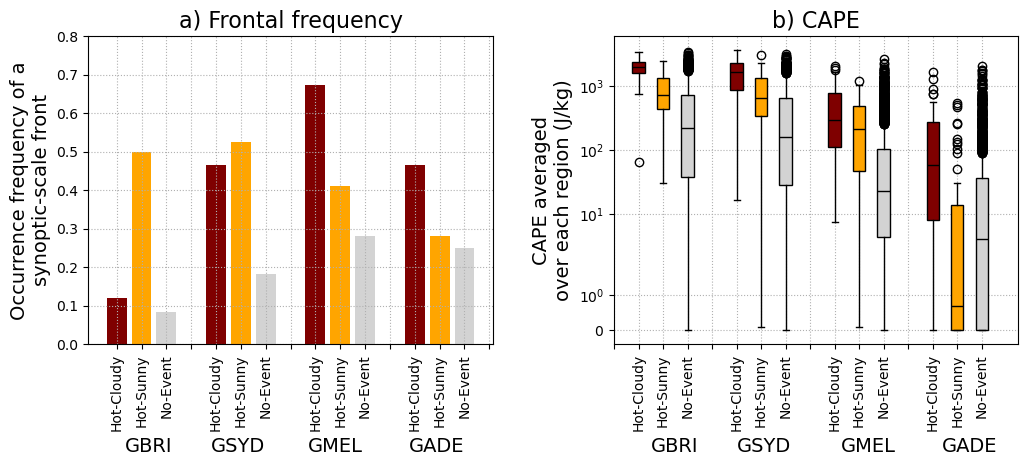

In [150]:
    


plt.figure(figsize=[12,4])
ax1=plt.subplot(1,2,1)
ax2=plt.subplot(1,2,2)
plot_cape_fronts(cape_front_df_1,ax1,ax2,text=True,ylab=True,xticks=True)
ax1.set_title("a) Frontal frequency",size=16)
ax2.set_title("b) CAPE",size=16)
plt.subplots_adjust(wspace=0.3)
plt.savefig("/g/data/ng72/ab4502/hot-cloudy/figs/fronts_cape_q.jpeg",dpi=400,bbox_inches="tight")

0
1
2
3
0
1
2
3
0
1
2
3
0
1
2
3


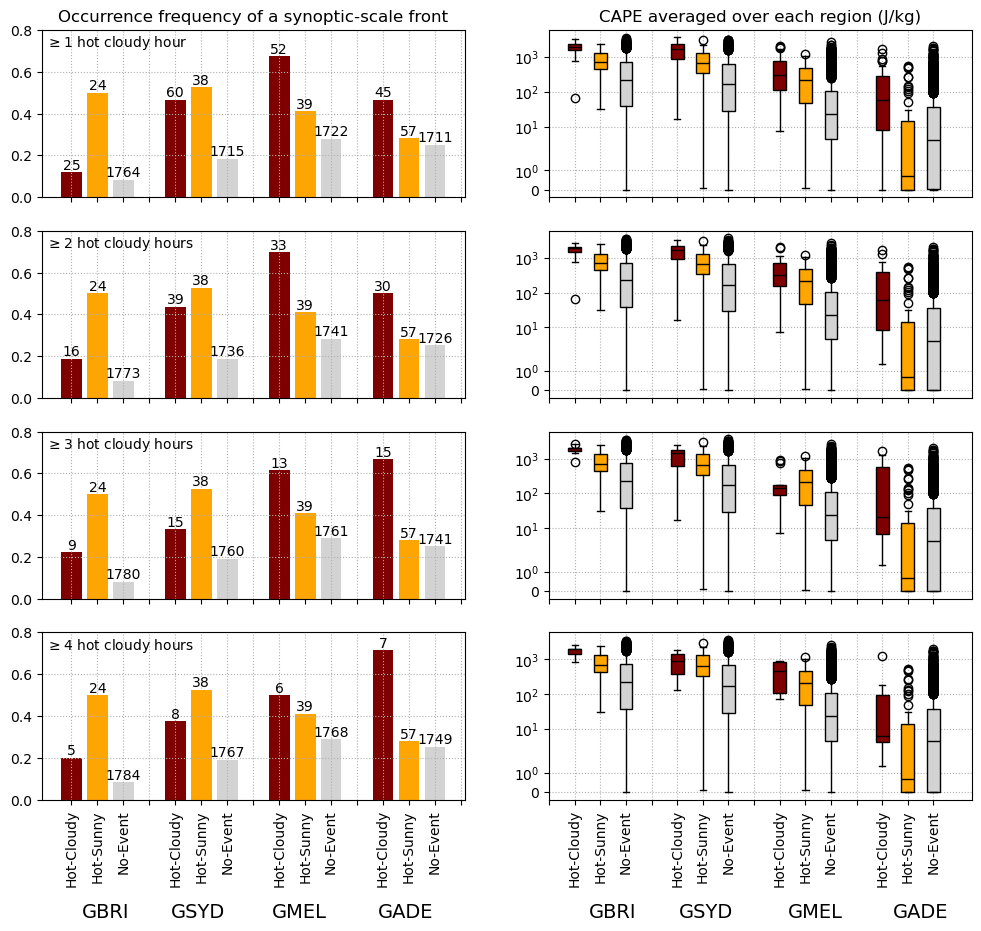

In [151]:
plt.figure(figsize=[12,10])
ax1=plt.subplot(4,2,1)
ax2=plt.subplot(4,2,2)
plot_cape_fronts(cape_front_df_1,ax1,ax2,print_samples=True)
ax1.set_title("Occurrence frequency of a synoptic-scale front")
ax2.set_title("CAPE averaged over each region (J/kg)")
ax1.text(0.01,0.9,"$\geq $1 hot cloudy hour",transform=ax1.transAxes)

ax1=plt.subplot(4,2,3)
plot_cape_fronts(cape_front_df_2,ax1,plt.subplot(4,2,4),print_samples=True)
ax1.text(0.01,0.9,"$\geq $2 hot cloudy hours",transform=ax1.transAxes)

ax1=plt.subplot(4,2,5)
plot_cape_fronts(cape_front_df_3,ax1,plt.subplot(4,2,6),print_samples=True)
ax1.text(0.01,0.9,"$\geq $3 hot cloudy hours",transform=ax1.transAxes)

ax1=plt.subplot(4,2,7)
plot_cape_fronts(cape_front_df_4,ax1,plt.subplot(4,2,8),xticks=True,text=True,text_ypad=-0.7,print_samples=True)
ax1.text(0.01,0.9,"$\geq $4 hot cloudy hours",transform=ax1.transAxes)

plt.savefig("/g/data/ng72/ab4502/hot-cloudy/figs/fronts_cape_q_test.jpeg",dpi=400,bbox_inches="tight")

In [27]:
mean_f = f_daily.mean("date").persist()


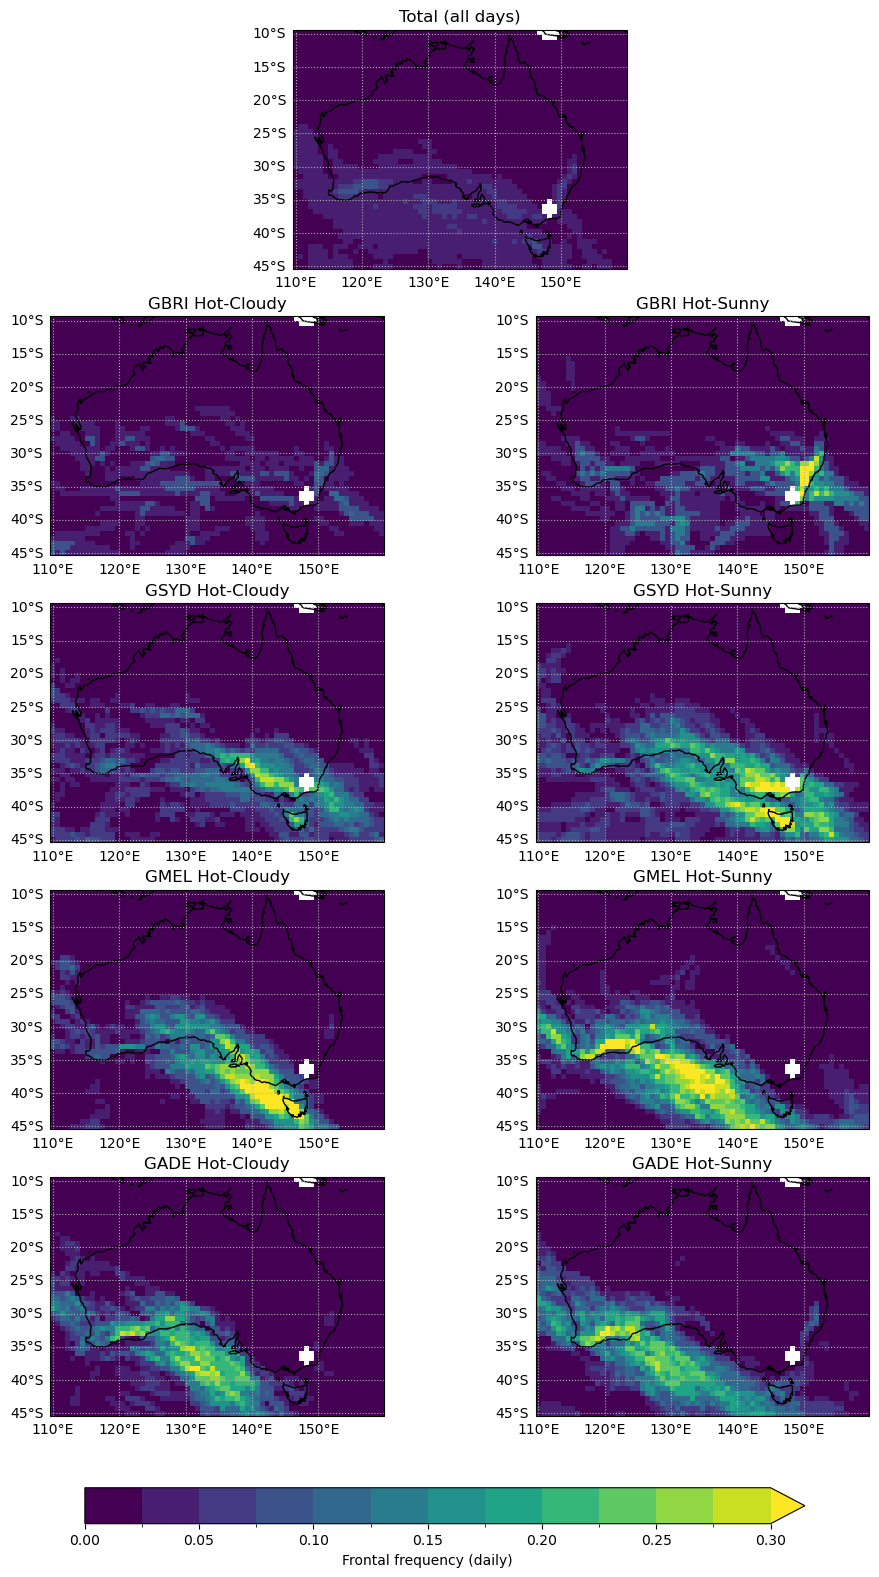

In [31]:
def plot(ax,front):

    front_levs=np.arange(0,0.325,0.025)
    
    xr.plot.pcolormesh(front,levels=front_levs,extend="max",add_colorbar=False)
    ax.coastlines()
    ax.gridlines(ls=":",draw_labels=["left","bottom"])

cnt=1

plt.figure(figsize=[12,18])
for region,i in zip(["GBRI","GSYD","GMEL","GADE"],[0,1,2,3]):

    ax=plt.subplot2grid((5,4),(cnt,0),colspan=2,projection=ccrs.PlateCarree())
    plot(ax,xr.where(front_f.barra_r_missing.isel(time=0),np.nan,front_freq_ls_cases[i]))
    plt.title(region + " Hot-Cloudy")
        
    ax=plt.subplot2grid((5,4),(cnt,2),colspan=2,projection=ccrs.PlateCarree())
    plot(ax,xr.where(front_f.barra_r_missing.isel(time=0),np.nan,front_freq_ls_nulls[i]))
    plt.title(region + " Hot-Sunny")

    cnt=cnt+1


ax=plt.subplot2grid((5,4),(0,1),colspan=2,projection=ccrs.PlateCarree())
c=xr.where(front_f.barra_r_missing.isel(time=0),np.nan,mean_f).plot(levels=np.arange(0,0.325,0.025),extend="max",add_colorbar=False)
ax.coastlines()    
plt.title("Total (all days)")
ax.gridlines(ls=":",draw_labels=["left","bottom"])
cb=plt.colorbar(c,plt.axes([0.2,0.05,0.6,0.02]),orientation="horizontal")
cb.set_label("Frontal frequency (daily)")

plt.savefig("/g/data/ng72/ab4502/hot-cloudy/figs/fronts_map.jpeg",dpi=400,bbox_inches="tight")

In [29]:
mean_cape = cape_all_daily.mean("date")

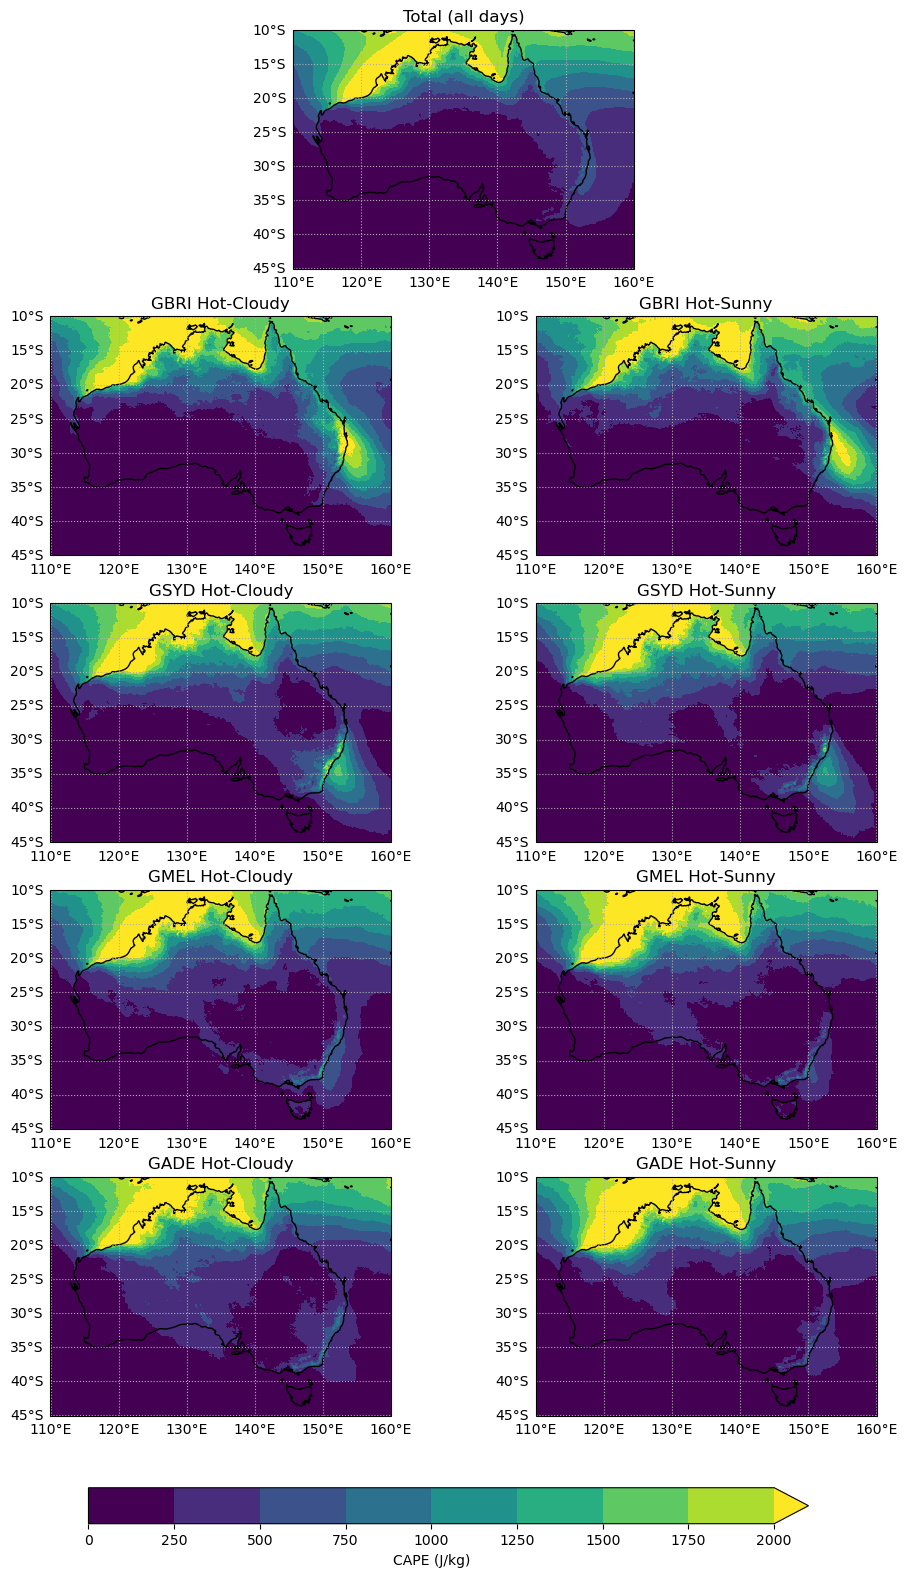

In [30]:
def plot(ax,cape):

    cape_levs=np.arange(0,2250,250)
    
    xr.plot.pcolormesh(cape,levels=cape_levs,extend="max",add_colorbar=False)
    ax.coastlines()
    ax.gridlines(ls=":",draw_labels=["left","bottom"])

cnt=1

plt.figure(figsize=[12,18])
for region,i in zip(["GBRI","GSYD","GMEL","GADE"],[0,1,2,3]):


    ax=plt.subplot2grid((5,4),(cnt,0),colspan=2,projection=ccrs.PlateCarree())
    plot(ax,cape_mean_cases[i])
    plt.title(region + " Hot-Cloudy")
        
    ax=plt.subplot2grid((5,4),(cnt,2),colspan=2,projection=ccrs.PlateCarree())
    plot(ax,cape_mean_nulls[i])
    plt.title(region + " Hot-Sunny")

    cnt=cnt+1


ax=plt.subplot2grid((5,4),(0,1),colspan=2,projection=ccrs.PlateCarree())
c=mean_cape.plot(levels=np.arange(0,2250,250),extend="max",add_colorbar=False)
ax.coastlines()    
plt.title("Total (all days)")
ax.gridlines(ls=":",draw_labels=["left","bottom"])
cb=plt.colorbar(c,plt.axes([0.2,0.05,0.6,0.02]),orientation="horizontal")
cb.set_label("CAPE (J/kg)")